For this dataset, there is already an experimental clustering scope available. In this notebook, we will simulate a clustering scope using the yield prediction model to estimate the performance of the resulting scopes.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..','..')))
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.cluster import hierarchy
from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt
from rdkit import Chem
from matplotlib.lines import Line2D
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from sklearn.preprocessing import scale
from matplotlib.patches import Patch
from scipy.spatial.distance import cdist
import numpy as np
from Code.predictor import ScopeBO
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
from Code.benchmark import Benchmark
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import colorsys


# Doyle colors
doyle_colors = ["#CE4C6F", "#1561C2", "#188F9D","#C4ADA2","#515798", "#CB7D85", "#A9A9A9"]
# extension of palette with lighter and darker versions
def adjust_lightness(color, factor=1.2):
    """
    Function to make colors lighter (factor > 1) or darker (factor < 1).
    """
    r, g, b = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = max(0, min(1, l * factor))
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return mcolors.to_hex((r, g, b))

lighter = [adjust_lightness(c, 1.2) for c in doyle_colors]
darker  = [adjust_lightness(c, 0.7) for c in doyle_colors]
all_colors = doyle_colors + darker[::-1] + lighter[::-1] 

# Save the categorical colormap
cat_cmap = ListedColormap(all_colors, name="Doyle_cat")
plt.colormaps.register(cat_cmap)

# Define and save a continuous colormap
colors = [doyle_colors[1],"#FFFFFFD1",doyle_colors[0]]
cont_cmap = LinearSegmentedColormap.from_list("Doyle_cont", colors)
plt.colormaps.register(cont_cmap)

# General plt parameters
plt.rcParams.update({
    "axes.titlesize": 20,        # Subplot title
    "axes.labelsize": 16,        # X and Y labels
    "figure.titlesize": 24,      # Suptitle
    "xtick.labelsize": 14,       # X tick labels
    "ytick.labelsize": 14,       # Y tick labels
    "legend.fontsize": 14,       # Legend text
    "legend.title_fontsize": 14, # Legend titles
    "font.family": "Helvetica"   # Font
    })

In [2]:
# function to show the molecular structure of the selected compounds
def generate_representation(smiles_list,common_core="c1ccccc1I"):
    # Convert to molecules
    mol_list = [Chem.MolFromSmiles(smiles) for smiles in smiles_list]

    # Generate 2D coordinates for all mols
    for mol in mol_list:
        AllChem.Compute2DCoords(mol)

    # Define iodobenzene substructure for alignment
    core = Chem.MolFromSmarts(common_core)
    AllChem.Compute2DCoords(core)

    # Align each molecule to the substructure if it matches
    for mol in mol_list:
        if mol.HasSubstructMatch(core):
            AllChem.GenerateDepictionMatching2DStructure(mol, core)

    return mol_list

In [3]:
# get the normalization bounds
dfs_bounds_greedy = {}
for metric in ["yield","vendi"]:
    dfs_metric = {}
    for batch_size in [1,3,4]:
        dfs_metric[batch_size] = Benchmark().heatmap_plot(type_results=metric,name_results=f"./Results_Data/bounds/greedy40_b{batch_size}",budget=40,show_plot=False)
    greedy_values = pd.concat(dfs_metric,axis=1)
    greedy_values.columns = [1,3,4]
    greedy_values = greedy_values.stack().reset_index(drop=True)
    dfs_bounds_greedy[metric] = pd.DataFrame({metric: greedy_values})
bounds_greedy = pd.concat(dfs_bounds_greedy,axis=1)
bounds_greedy.columns = ["yield","vendi"]
yield_max = bounds_greedy["yield"].max()
vendi_min = bounds_greedy["vendi"].min()
print(f"upper bounds yield: {yield_max}")
print(f"lower bounds vendi score: {vendi_min}")
dfs_bounds_explorative = {}
for metric in ["yield","vendi"]:
    dfs_metric = {}
    for batch_size in [1,3,4]:
        dfs_metric[batch_size] = Benchmark().heatmap_plot(type_results=metric,
                                                          name_results=f"./Results_Data/bounds"\
                                                            f"/explorative40_b{batch_size}",
                                                            budget=40,show_plot=False)
    explorative_values = pd.concat(dfs_metric,axis=1)
    explorative_values.columns = [1,3,4]
    explorative_values = explorative_values.stack().reset_index(drop=True)
    dfs_bounds_explorative[metric] = pd.DataFrame({metric: explorative_values})
bounds_explorative = pd.concat(dfs_bounds_explorative,axis=1)
bounds_explorative.columns = ["yield","vendi"]
yield_min = bounds_explorative["yield"].min()
vendi_max = bounds_explorative["vendi"].max()
print(f"lower bounds yield: {yield_min}")
print(f"upper bounds vendi score: {vendi_max}")
# Record the bounds
yield_bounds = (yield_max,yield_min)
vendi_bounds = (vendi_max,vendi_min)
bounds = {"yield":yield_bounds,"vendi":vendi_bounds}

upper bounds yield: 60.25691937316729
lower bounds vendi score: 1.5966915696066428
lower bounds yield: 30.465668016857883
upper bounds vendi score: 6.05675840987693


In [4]:
# function to calculate the scope score
def calculate_scope_score(av_yield,Vendi_score,bounds):
    scaled_rate = (av_yield - bounds["yield"][1])/(bounds["yield"][0] - bounds["yield"][1])
    scaled_Vendi = (Vendi_score - bounds["vendi"][1])/(bounds["vendi"][0] - bounds["vendi"][1])

    return scaled_rate * scaled_Vendi

In [5]:
# define a couple things
objectives = ["yield"]
directory = "."
wdir = Path(directory)

In [6]:
# Load the data (pre-processing was already carried out in the curation of the read-in dataset)
df_labelled = pd.read_csv(f"./arbr_dset.csv", index_col=0,header=0)
df_data = df_labelled.copy(deep=True)
df_data = df_data.drop(columns='yield')  # drop the objective values

# Scale the data
df_data = pd.DataFrame(scale(df_data),df_data.index,df_data.columns)

# make a 2D-UMAP for the dataset
fit = UMAP(n_neighbors=40,min_dist=0.7,n_components=2,metric="euclidean",random_state=12)
df_umap = pd.DataFrame(fit.fit_transform(df_data),df_data.index,["UMAP1","UMAP2"])
print(f"There are {len(df_data.columns)} dimensions in the dataset.")

There are 32 dimensions in the dataset.


In [7]:
# define the dimensionalities of the reduced representation to study
dims = [32, 30, 25, 20, 15, 10, 5, 2]

In [8]:
# function to calculate silhouette scores
def silhouette_scores_hierarchical(data, n_cls_list):
    """helper function to compute a silhouette score for hierarchical clustering using Ward linkage"""
    z = linkage(data, method='ward')
    result = pd.Series(index=n_cls_list, dtype=float)
    for n_cls in n_cls_list:
        cls = fcluster(z, n_cls, criterion='maxclust')
        result.loc[n_cls] = silhouette_score(data, cls)
    return result

In [9]:
# dictionary to store data at different levels of dimensionality reduction
n_neighbors = int(np.sqrt(df_data.shape[1]))
dfs = {}
for dim in dims:
    key = f"umap{dim}"
    dfs[key] = pd.DataFrame(UMAP(n_components=dim, n_neighbors=n_neighbors,
                                    random_state=0).fit_transform(df_data),index=df_data.index)

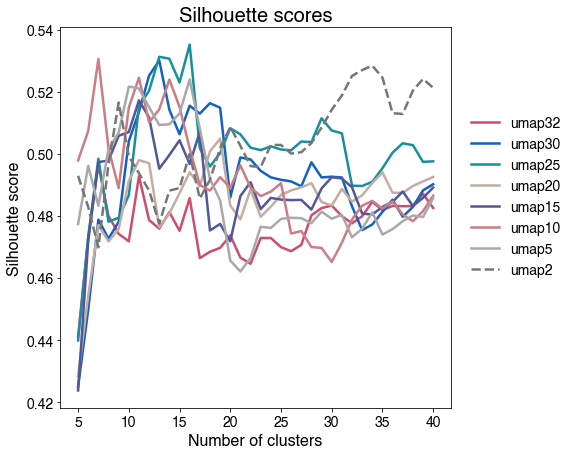

,Representation,Nr_clusters,Silh_score,Representation (min 15 clusters),Nr_clusters (min 15 clusters),Silh_score (min 15 clusters)
Results,umap25,16.0,0.535211,umap25,16.0,0.535211


In [10]:
# range of scope sizes to be studied
N_CLS_list = list(range(5,41))
# min number of clusters for the scope
min_clust = 15
# df to save the results of the silhouette score analysis
best_silh_scores = pd.DataFrame(np.nan,index=["Results"],columns=["Representation","Nr_clusters", "Silh_score",
                                                               f"Representation (min {min_clust} clusters)", 
                                                               f"Nr_clusters (min {min_clust} clusters)",
                                                               f"Silh_score (min {min_clust} clusters)"])

plt.figure(figsize=(7,7))
plt.title("Silhouette scores")
plt.xlabel("Number of clusters",fontsize=16)
plt.ylabel("Silhouette score",fontsize=16)

# populate silhouette scores for all number of clusters and all dimensionality reductions
silh_scores = pd.DataFrame(index=N_CLS_list)
for key, value in dfs.items():
    silh_scores[key] = silhouette_scores_hierarchical(value, N_CLS_list)
for j,col in enumerate(silh_scores.columns):
    style = '-' if j <= 6 else '--' if j <= 13 else ':'
    plotting = silh_scores[col][silh_scores[col].notna()]
    plt.plot(plotting.index, plotting.values, label = col, color=all_colors[j], linestyle=style, linewidth=2.5)

# record the representation that gives the best silhouette score
max_position = silh_scores.stack().idxmax()
best_silh_scores.loc["Results","Representation"] = max_position[1]
best_silh_scores.loc["Results","Nr_clusters"] = int(max_position[0])
best_silh_scores.loc["Results","Silh_score"] = silh_scores.max().max()
silh_scores_pruned = silh_scores.loc[silh_scores.index >= min_clust]
max_position_pruned = silh_scores_pruned.stack().idxmax()
best_silh_scores.loc["Results",f"Representation (min {min_clust} clusters)"] = max_position_pruned[1]
best_silh_scores.loc["Results",f"Nr_clusters (min {min_clust} clusters)"] = int(max_position_pruned[0])
best_silh_scores.loc["Results",f"Silh_score (min {min_clust} clusters)"] = silh_scores_pruned.max().max()
plt.legend(loc='center left',
           frameon =False,
           bbox_to_anchor=(1.02, 0.555))
plt.show()

best_silh_scores

In [11]:
embedding = best_silh_scores.loc["Results",f"Representation (min {min_clust} clusters)"]
nr_clusters = best_silh_scores.loc["Results",f"Nr_clusters (min {min_clust} clusters)"]

# Clustering
z = hierarchy.linkage(dfs[embedding],method ="ward",metric="euclidean")
clusters = hierarchy.fcluster(z,nr_clusters,criterion="maxclust")

# Assign to samples
df_data["clusters"] = clusters
df_umap["clusters"] = clusters

Visualization of the clusters:


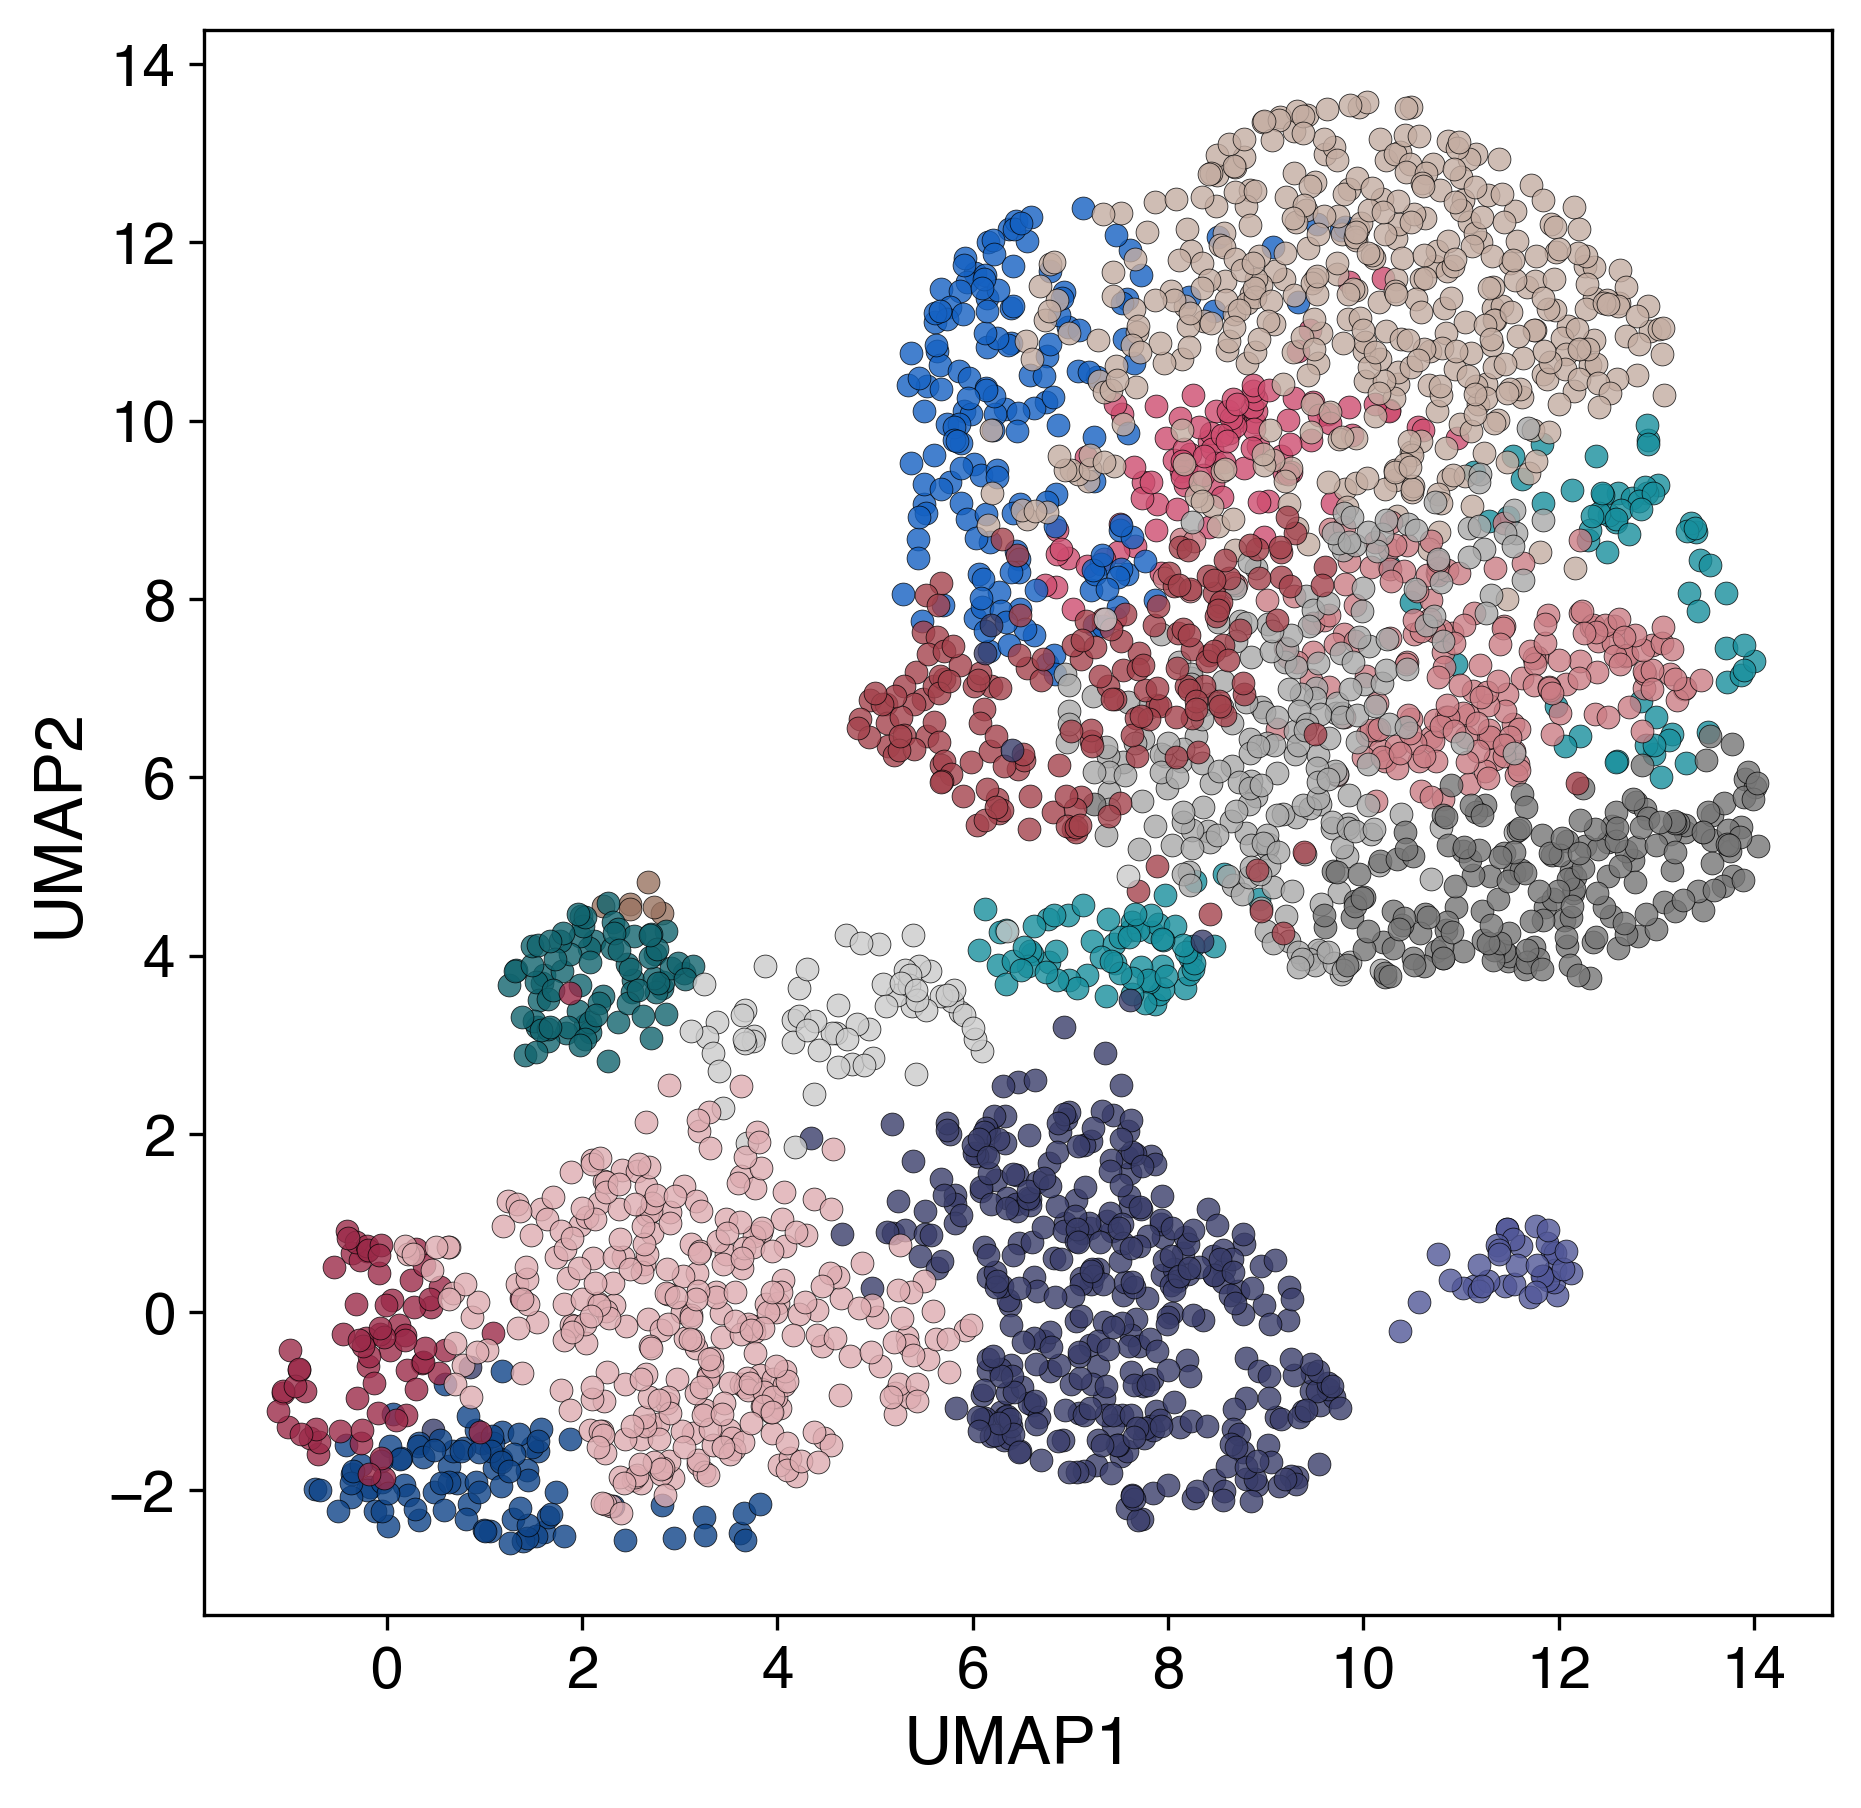

Please note that some colors only differ in the shade due to the large number of clusters. Some colors are also used for two clusters.


In [12]:
# draw the clusters
print("Visualization of the clusters:")

# making sure there are enough colors
all_colors = all_colors * 4

plt.figure(figsize=(7,7),dpi=300)
plt.xlabel("UMAP1",fontsize=16)
plt.ylabel("UMAP2",fontsize=16)

for cluster_id in sorted(df_umap['clusters'].unique()):
    color_id = cluster_id-1  # colors are zero-index, but clusters one-indexed
    cluster_data = df_umap[df_umap['clusters'] == cluster_id]
    plt.scatter(
        cluster_data['UMAP1'], cluster_data['UMAP2'],
        color=all_colors[color_id],
        label=f'Cluster {cluster_id}',
        s=30, alpha=0.8, edgecolor='k', linewidth=0.2
    )
plt.show()
print("Please note that some colors only differ in the shade due to the large number of clusters. Some colors are also used for two clusters.")

In [13]:
# calculate the center-most point of each cluster and the Vendi score for the resulting samples
scope_results = pd.DataFrame(np.nan,index=["Results"],columns=["Average yield","Vendi score","Scope score"])

cluster_yields = [] # list to save the yield
df_vendi = df_labelled.copy(deep=True)
df_vendi["yield"] = "PENDING"  # reset the yield data so that only the selected points will have a yield
for cluster in range(max(df_data["clusters"].unique())):  # loop through all clusters
    cluster = cluster+1  # +1 because the range object is 0-indexed whereas the cluster are 1-indexed
    df_cluster = df_data.loc[df_data["clusters"]== cluster]  # look at the points in the current cluster
    df_cluster = df_cluster.drop(columns=["clusters"])  # drop the cluster column to only keep the features (df_clustering did not contain the yield data)
    centroid = df_cluster.mean().values  # this is the center of the cluster
    distances = cdist(df_cluster,[centroid],metric="cityblock").flatten()  # calculate the distances to the center
    df_cluster["distances"] = distances
    centermost_point = df_cluster[df_cluster["distances"] == df_cluster["distances"].min()].index.to_list()[0]  # get the center-most point
    yield_clusterpoint = df_labelled.at[centermost_point,"yield"]  # get the yield data for the center-most point
    df_vendi.loc[centermost_point,"yield"] = "1"  # put a label for the vendi score calculation (value is not important)
    cluster_yields.append(yield_clusterpoint)  # save the point
av_yield = sum(cluster_yields)/len(cluster_yields)

scope_results.loc["Results","Average yield"] = av_yield
df_vendi.to_csv(wdir.joinpath("df_clustering_vendi.csv"),index=True,header=True)  # save the file (as the Vendi score calculation needs a file as input)
Vendi_score = ScopeBO().get_vendi_score(objectives=["yield"],directory=".",filename="df_clustering_vendi.csv")  # calculate the vendi score
scope_results.loc["Results","Vendi score"] = Vendi_score
scope_score = calculate_scope_score(av_yield,Vendi_score,bounds)
scope_results.loc["Results","Scope score"] = scope_score

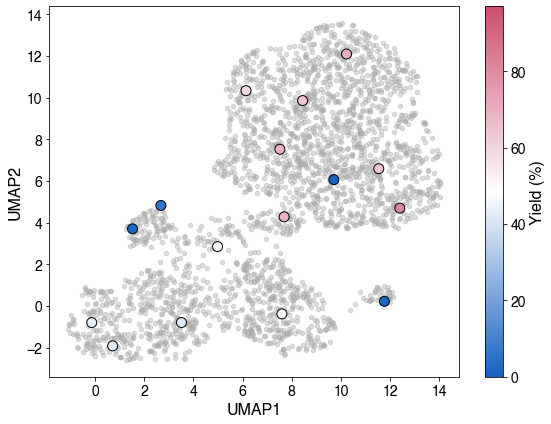

Scope results:


,Average yield,Vendi score,Scope score
Results,44.625826,1.845795,0.026547


In [14]:
plt.figure(figsize=(8,6))
plt.xlabel("UMAP1",fontsize=16)
plt.ylabel("UMAP2",fontsize=16)

# only keep the objective label for evaluated points
df_umap["yield"] = df_labelled["yield"]

for idx in df_vendi.index:
    if df_vendi.loc[idx,"yield"] == "PENDING":
        df_umap.loc[idx,"yield"] = "PENDING"

# Separate numeric and non-numeric (e.g., "PENDING") entries
df_numeric = df_umap[pd.to_numeric(df_umap['yield'], errors='coerce').notna()].copy()
df_numeric['yield'] = df_numeric['yield'].astype(float)
df_pending = df_umap[pd.to_numeric(df_umap['yield'], errors='coerce').isna()]

# Define colormap and normalization
vmin = df_labelled['yield'].min()
vmax = df_labelled['yield'].max()
norm = plt.Normalize(vmin, vmax)
cmap = sns.color_palette("Doyle_cont", as_cmap=True)

# Plot non-numeric entries ("PENDING")
plt.scatter(df_pending["UMAP1"], df_pending["UMAP2"], color=all_colors[6], s=20, alpha=0.4, label="PENDING")
# Plot numeric entries
scatter_numeric = plt.scatter(df_numeric["UMAP1"],df_numeric["UMAP2"],c=df_numeric["yield"],
                              cmap=cmap,norm=norm,s=100,alpha=1,edgecolor='k',linewidth=1)
# Add colorbar
cbar = plt.colorbar(scatter_numeric)
cbar.set_label("Yield (%)")

plt.tight_layout()
plt.show()
print("Scope results:")
scope_results

The Vendi score is very similar to the experimental clustering scope (2.00), but the average yieldi is lowered (55.7% in exp.). This is a further indication that the yield prediction model is underpredicting. Compared to ScopeBO (40.8±4.6%), the clustering scope average yield is higher, but the ScopeBO yield using a designed initiation according to our recommened workflow is higher (48.5%).

Doyle clustering scope:


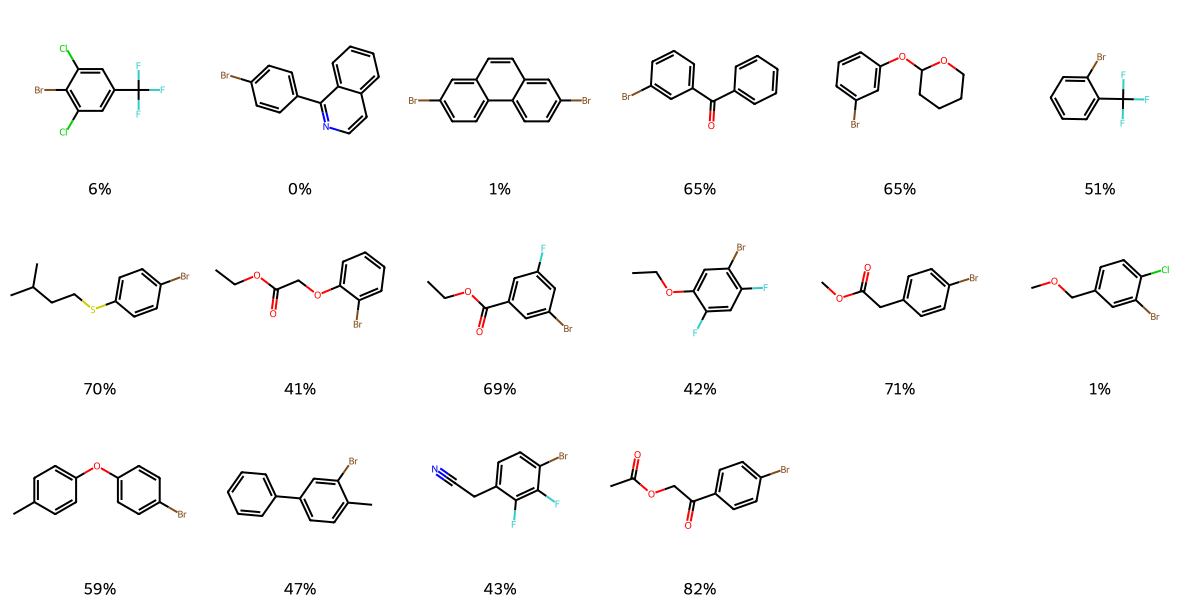

In [19]:
# show the selected molecules
print(f"Doyle clustering scope:")
df_selected = df_umap.loc[df_umap["yield"] != "PENDING"]
doyle_scope = {idx: df_selected.loc[idx,"yield"] for idx in df_selected.index}
depiction = Draw.MolsToGridImage(
    [Chem.MolFromSmiles(smi) for smi in doyle_scope.keys()],
    molsPerRow=6,
    subImgSize=(200, 200),
    legends=[f"{round(val)}%" for val in doyle_scope.values()]
    )
display(depiction)